# SWOT Analyses Using Customer Google Map Business Reviews (Marriot Hotels Ikeja)

In [1]:
!pip install evaluate

In [65]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from nltk.corpus import stopwords
import nltk
import ast
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from transformers import pipeline
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split
import torch
from datasets import Dataset
import evaluate
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer

In [66]:
conn = sqlite3.connect(r"C:\Users\USER\Documents\MY PORTFOLIO\google-reviews-scraper-pro\reviews.db")

In [67]:
df = pd.read_sql_query("SELECT * FROM reviews where place_id == '0x103b921776d4cd3f:0'", conn)

In [68]:
df

,review_id,place_id,author,rating,review_text,review_date,raw_date,likes,user_images,s3_images,...,owner_responses,created_date,last_modified,last_seen_session,last_changed_session,is_deleted,content_hash,engagement_hash,row_version,sub_ratings
0,Ci9DQUlRQUNvZENodHljRjlvT2xwT2JsVldiVGw2VVhoeV...,0x103b921776d4cd3f:0,Afam Eghosa,0.0,"{""en"": ""My stay was really enjoyable from star...",2026-05-23T15:03:14+00:00,a month ago on\nGoogle,0,[],None,...,{},2026-06-22T15:03:14.359339+00:00,2026-06-22T15:03:14.359339+00:00,1,1,0,9e1842e263ec7784973d27ba4457612ca1107e0badaeec...,3d3bc3d06f185da393e78bc15e715efd29d420d0d7f06c...,1,{}
1,Ci9DQUlRQUNvZENodHljRjlvT21oaVJuRk5lRkV4VG1GWl...,0x103b921776d4cd3f:0,judith jolayemi,0.0,"{""en"": ""It is always a great experience here. ...",2026-03-24T15:03:14+00:00,3 months ago on\nGoogle,0,"[""https://lh3.googleusercontent.com/grass-cs/A...",None,...,{},2026-06-22T15:03:14.617760+00:00,2026-06-22T15:03:14.617760+00:00,1,1,0,96d7da4636511f85c447fdd635e39e723a02d952f4b76f...,3d3bc3d06f185da393e78bc15e715efd29d420d0d7f06c...,1,{}
2,Ci9DQUlRQUNvZENodHljRjlvT21wRVYya3pOV0pqY1U1eV...,0x103b921776d4cd3f:0,Don Miller,0.0,"{""en"": ""Very nice. And whe. You compare it to...",2026-02-22T15:03:14+00:00,4 months ago on\nGoogle,0,"[""https://lh3.googleusercontent.com/grass-cs/A...",None,...,{},2026-06-22T15:03:14.793259+00:00,2026-06-22T15:03:14.793259+00:00,1,1,0,593d755d6bd27a6cd708acd9b67a53c8768561367ee418...,3d3bc3d06f185da393e78bc15e715efd29d420d0d7f06c...,1,{}
3,Ci9DQUlRQUNvZENodHljRjlvT2pWdlUwTmhWalpZWjJ4RW...,0x103b921776d4cd3f:0,Temitope Ifegbesan,0.0,"{""en"": ""Beautiful place. I went there for an e...",2026-05-25T15:03:14+00:00,4 weeks ago on\nGoogle,0,[],None,...,{},2026-06-22T15:03:14.959840+00:00,2026-06-22T15:03:14.959840+00:00,1,1,0,5383a6fa1aeb402c24c6cd16e558ecce2367d35bf7772a...,3d3bc3d06f185da393e78bc15e715efd29d420d0d7f06c...,1,{}
4,Ci9DQUlRQUNvZENodHljRjlvT2xaWGNFVmpXWGN6ZVZkV2...,0x103b921776d4cd3f:0,Olu O,0.0,"{""en"": ""It’s a rather beautiful property; quit...",2025-12-24T15:03:15+00:00,6 months ago on\nGoogle,0,"[""https://lh3.googleusercontent.com/grass-cs/A...",None,...,{},2026-06-22T15:03:15.123500+00:00,2026-06-22T15:03:15.123500+00:00,1,1,0,5b46f486b787b0e296ccff6e26236717f9ae437aad5a3c...,3d3bc3d06f185da393e78bc15e715efd29d420d0d7f06c...,1,{}
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1235,ChdDSUhNMG9nS0VJQ0FnSUR1bjRidTl3RRAB,0x103b921776d4cd3f:0,Michael Umeji,0.0,"{""en"": ""Great ambience.\nGreat food.\nCourteou...",2023-06-23T15:33:40+00:00,3 years ago on\nGoogle,0,[],None,...,{},2026-06-22T15:33:40.943648+00:00,2026-06-22T15:33:40.943648+00:00,1,1,0,b1c9744586cdff1fd68174adb6d72879ebb19bbda96ac9...,3d3bc3d06f185da393e78bc15e715efd29d420d0d7f06c...,1,{}
1236,ChdDSUhNMG9nS0VJQ0FnSUR1azVtVWhRRRAB,0x103b921776d4cd3f:0,Oluwayomi Emmanuel,0.0,"{""en"": ""Luxury is the word when Marriott Hotel...",2023-06-23T15:33:41+00:00,3 years ago on\nGoogle,1,[],None,...,"{""en"": {""text"": ""Thank you so much for your ki...",2026-06-22T15:33:41.096230+00:00,2026-06-22T15:33:41.096230+00:00,1,1,0,6205c56a76ea2f1dd6055f04d4fd4b5812c3ee86293c1c...,3c54e88e20a38369a12078950f4ef22950959c671bf263...,1,{}
1237,ChdDSUhNMG9nS0VJQ0FnSUM1a1pXZl9RRRAB,0x103b921776d4cd3f:0,Clement Olawoye,0.0,"{""en"": ""I really enjoyed my stay...\nLagos Mar...",2024-06-22T15:33:41+00:00,2 years ago on\nGoogle,0,[],None,...,{},2026-06-22T15:33:41.659973+00:00,2026-06-22T15:33:41.659973+00:00,1,1,0,ebb3ef5f10009436432b0aa489c10819c11150b102130b...,3d3bc3d06f185da393e78bc15e715efd29d420d0d7f06c...,1,{}
1238,ChdDSUhNMG9nS0VJQ0FnSUNtOVp6RGlnRRAB,0x103b921776d4cd3f:0,Nnabuihe Ikechukwu,0.0,"{""en"": ""Same international standard with other...",2022-06-23T15:33:41+00:00,4 years ago on\nGoogle,0,[],None,...,"{""en"": {""text"": ""Thank you so much for your ki...",2026-06-22T15:33:41.792563+00:00,2026-06-22T15:33:41.792563+00:00,1,1,0,365ec647b5d48a0b96627d9f1c81696ac423585adec1d

In [69]:
df["review_text"] = (
    df["review_text"]
    .apply(ast.literal_eval)
    .apply(lambda x: x.get("en"))
)

In [70]:
df.columns

Index(['review_id', 'place_id', 'author', 'rating', 'review_text',
       'review_date', 'raw_date', 'likes', 'user_images', 's3_images',
       'profile_url', 'profile_picture', 's3_profile_picture',
       'owner_responses', 'created_date', 'last_modified', 'last_seen_session',
       'last_changed_session', 'is_deleted', 'content_hash', 'engagement_hash',
       'row_version', 'sub_ratings'],
      dtype='object')

In [8]:
# Needed data for analyses

new_df = df.filter(["author", "rating", "review_text", "review_date", "likes"])

In [9]:
new_df.isna().sum()

author         0
rating         0
review_text    0
review_date    0
likes          0
dtype: int64

In [10]:
new_df.head()

,author,rating,review_text,review_date,likes
0,Afam Eghosa,0.0,My stay was really enjoyable from start to fin...,2026-05-23T15:03:14+00:00,0
1,judith jolayemi,0.0,It is always a great experience here. Food was...,2026-03-24T15:03:14+00:00,0
2,Don Miller,0.0,Very nice. And whe. You compare it to outside...,2026-02-22T15:03:14+00:00,0
3,Temitope Ifegbesan,0.0,Beautiful place. I went there for an event and...,2026-05-25T15:03:14+00:00,0
4,Olu O,0.0,It’s a rather beautiful property; quite busy a...,2025-12-24T15:03:15+00:00,0


In [11]:
# Inspect text
new_df["review_text"].to_list()

['My stay was really enjoyable from start to finish. The atmosphere was calm, classy, and welcoming the moment I arrived, and the staff were friendly, helpful, and respectful throughout my stay.\n\nCheck-in was smooth and stress-free, and I immediately noticed how clean and beautiful the hotel looked. My room was spacious, neat, and very comfortable. The bed was soft, the lighting felt warm and relaxing, and everything in the room was arranged thoughtfully. Housekeeping also did a great job keeping the room fresh and spotless every day.',
 'It is always a great experience here. Food was great. Everything was good-the ambience- the views and all. Im giving 3-star for their service because there was one of their managers who was so rash and rude to us during the buffet. Not such a good front.',
 "Very nice.  And whe. You compare it to outside the compound...almost heaven.   But armed guards use mirrors to check the cab for bombs and your luggage is xrayed and you pass through a metal det

In [12]:
# Quick text clean

new_df["review_text"] = (
    new_df["review_text"]
    .str.strip()
    .str.replace("\\n", " ", regex=False)
    .str.replace("\n", " ", regex=False)
    .str.strip()
)

In [13]:
new_df

,author,rating,review_text,review_date,likes
0,Afam Eghosa,0.0,My stay was really enjoyable from start to fin...,2026-05-23T15:03:14+00:00,0
1,judith jolayemi,0.0,It is always a great experience here. Food was...,2026-03-24T15:03:14+00:00,0
2,Don Miller,0.0,Very nice. And whe. You compare it to outside...,2026-02-22T15:03:14+00:00,0
3,Temitope Ifegbesan,0.0,Beautiful place. I went there for an event and...,2026-05-25T15:03:14+00:00,0
4,Olu O,0.0,It’s a rather beautiful property; quite busy a...,2025-12-24T15:03:15+00:00,0
...,...,...,...,...,...
1235,Michael Umeji,0.0,Great ambience. Great food. Courteous staff. 100%,2023-06-23T15:33:40+00:00,0
1236,Oluwayomi Emmanuel,0.0,Luxury is the word when Marriott Hotel is ment...,2023-06-23T15:33:41+00:00,1
1237,Clement Olawoye,0.0,I really enjoyed my stay... Lagos Marriott Hot...,2024-06-22T15:33:41+00:00,0
1238,Nnabuihe Ikechukwu,0.0,Same international standard with other Marriot...,2022-06-23T15:33:41+00:00,0


In [14]:
# check ratings and likes

print("Existing Unique Ratings: ", new_df["rating"].value_counts())
print("=" * 50)
print("Existing Unique Likes: ", new_df["likes"].value_counts())

Existing Unique Ratings:  rating
0.0    1240
Name: count, dtype: int64
Existing Unique Likes:  likes
0    1047
1     129
2      37
3      12
4       7
5       4
7       3
6       1
Name: count, dtype: int64


In [15]:
# Drop ratings since its irrelevant

new_df.drop("rating", axis=1, inplace=True)

In [16]:
# datetime handling

def datetime_cleaning(new_df):

    new_df["review_date"] = pd.to_datetime(new_df["review_date"])
    
    # Extract day, month, year month-year
    
    new_df["day"] = new_df["review_date"].dt.day_name()
    new_df["month"] = new_df["review_date"].dt.month_name()
    new_df["year"] = new_df["review_date"].dt.year
    
    
    # Lets get timing reviews are dropped
    # need hours
    new_df["hour"] = new_df["review_date"].dt.hour

    def hour_conv(hour):
        # morning
        if hour < 12:
            return "morning"
        elif hour < 17:
            return "afternoon"
        else:
            return "night"

    new_df["time"] = new_df["hour"].apply(hour_conv)

    return new_df

In [17]:
new_df = datetime_cleaning(new_df)

In [18]:
# Drop datetime column

new_df.drop("review_date", axis=1, inplace=True)

In [19]:
# Create month_year column

new_df["month_year"] = new_df.apply(lambda x: f"{x['month']}_{x['year']}", axis=1)

In [20]:
# Marriot started operation in 2021 and investigating reviews before 2021

timing = new_df.sort_values(ascending=False, by="year")
time = timing[timing["year"] < 2021]
time.review_text.to_list()

['This place is under construction... But i base on the information from one of the engineers: He said its a 5stars Hotel and to be completed this year 2019',
 'The Cool place for a weekend getaway.  The rooms are clean and spacious. The service was superb!',
 'Upcoming.  A place to visit once completed.  High class hotel with German engineered Grohe luxury fittings and accessories.']

In [85]:
len(new_df[new_df["year"] >= 2021])

1237

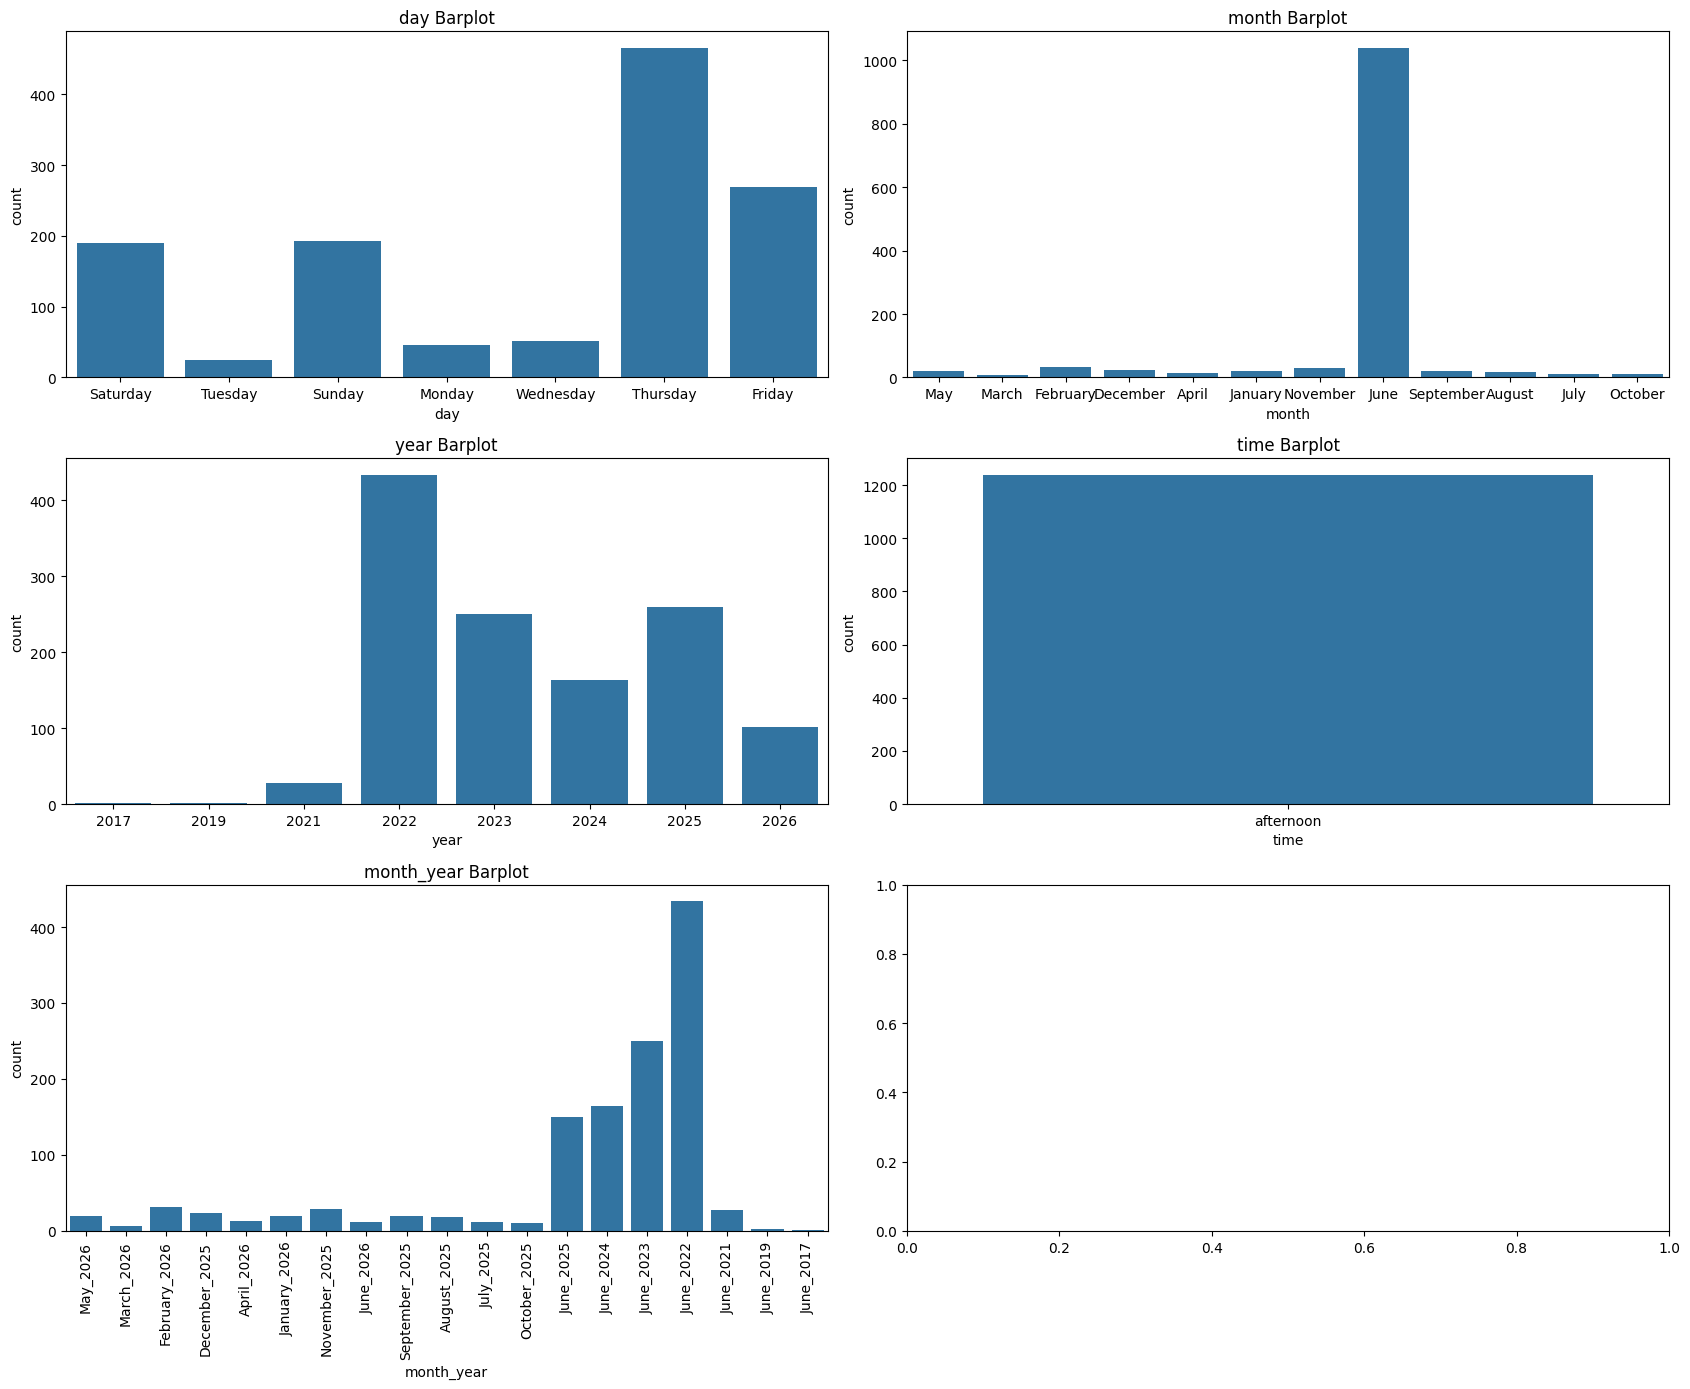

In [71]:
# Lets see the frequency at different day, month, year and time reviews are dropped the most

fig, axes = plt.subplots(3, 2, figsize=(17, 14))

cols = ["day", "month", "year", "time", "month_year"]

temp_df = new_df[cols]

for i, col in enumerate(temp_df.columns):

    row = i//2
    col_ind = i%2

    sns.countplot(x=temp_df[col], ax=axes[row, col_ind])
    axes[row,col_ind].set_title(f"{col} Barplot")
    if col == "month_year":
        axes[row, col_ind].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.savefig("marriot_days.png")
plt.show()

In [22]:
# Data timing validation

for i in temp_df.columns:
    print(f"Counts of {i} Events: {temp_df[i].value_counts()}")
    print("==" * 50)

Counts of day Events: day
Thursday     466
Friday       269
Sunday       193
Saturday     190
Wednesday     51
Monday        46
Tuesday       25
Name: count, dtype: int64
Counts of month Events: month
June         1040
February       32
November       29
December       23
January        19
May            19
September      19
August         18
April          13
July           11
October        10
March           7
Name: count, dtype: int64
Counts of year Events: year
2022    434
2025    260
2023    250
2024    164
2026    101
2021     28
2019      2
2017      1
Name: count, dtype: int64
Counts of time Events: time
afternoon    1240
Name: count, dtype: int64
Counts of month_year Events: month_year
June_2022         434
June_2023         250
June_2024         164
June_2025         150
February_2026      32
November_2025      29
June_2021          28
December_2025      23
May_2026           19
September_2025     19
January_2026       19
August_2025        18
April_2026         13
July_2025

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


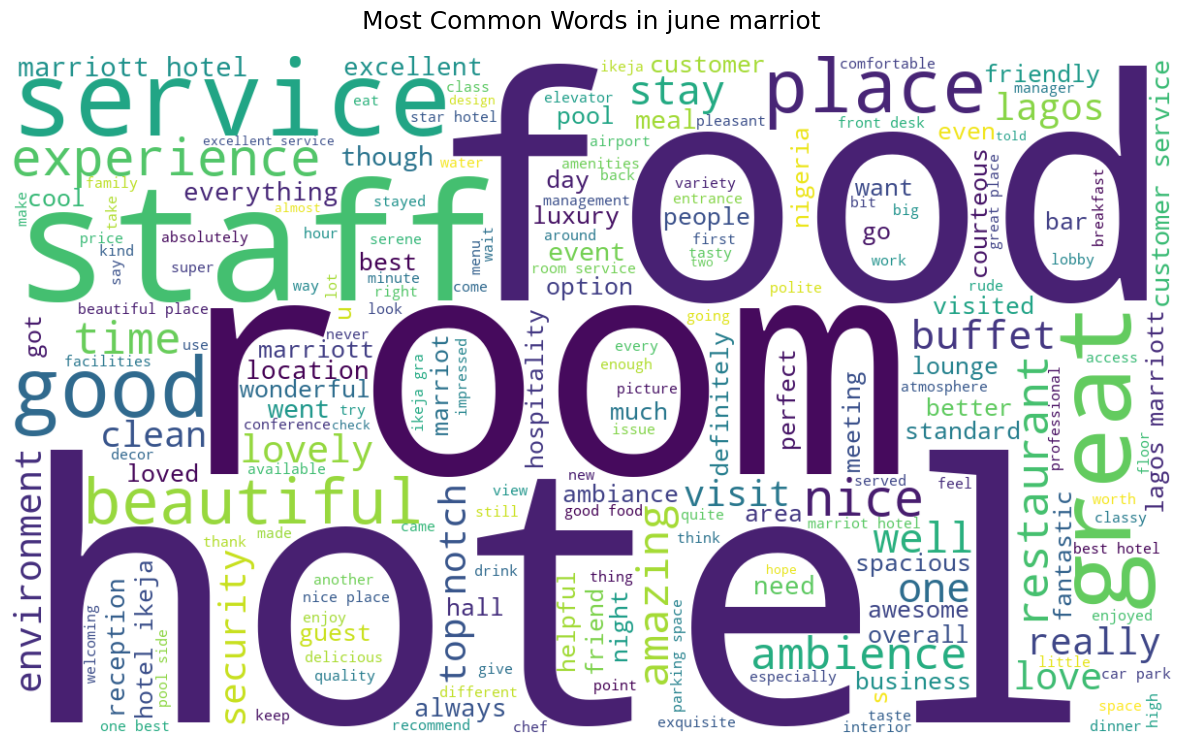

In [23]:
# What happens in june?
june = new_df[(new_df["month"] == "June") & (new_df["year"].isin([2022, 2023, 2024, 2025]))]


# What are they saying?
#clean stopwords
nltk.download("stopwords")

## put to a string
june_words = " ".join(june["review_text"].astype(str)).lower()

## stopwords unique
stop_words = set(stopwords.words("english"))

june_text = " ".join(word for word in june_words.split() if word not in stop_words)

# Word cloud
# Generate wordcloud

wordcloud = WordCloud(
    width=1200,
    height=700,
    background_color='white',
    max_words=200,
    colormap='viridis',     
    contour_color='black',
    contour_width=1,
    random_state=42
).generate(june_text)


plt.figure(figsize=(15, 9))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in june marriot', 
          fontsize=18, pad=20)
plt.show()

In [24]:
# Lets look at each review and bring out reviews were words likeevent or meetings was mentioned to test our hypothesis

events = [
    review
    for review in june["review_text"]
    if "event" in review.lower() or "meeting" in review.lower()
]
events

["The hotel is beautiful and service is great. One of the best hotels on the mainland and it's location and closeness to the airport is a plus. Attended a dinner event at the roof top recently. Nice ambience! Food could be better taste wise but salads was really nice and fresh. A bit dark for pictures but I understand that too much light would ruin the ambience and there was also a screen so no need for light. Would come back definitely.",
 'Hotel is fantastic and the service is great. Food is wonderful especially the breakfast buffet. Security is top notch and I like the fact that elevator access is contingent on your room card. I had a great time here meeting and networking with a host of pleasant people. Parking space is okay and it was just awesome all around. Will definitely go again.',
 'Amazing, ambience.  A great place to use for meeting, relaxation.  Excellent maintenance standards.  Has facilities for physically challenged persons,with accessibility signs',
 "Went for work at

## Reports for time data

**Note: About 17% of data was collected for analyses**
- Most reviews are dropped on thursdays, followed by fridays and sundays. While least are on tuesday and wednesdays
- Reviews data was collected in most recent, June appears to be the month we have received reviews the most
- 2022 and 2025 is the leading year in most collected reviews, although we are in the middle of 2026 and the year seem to be doing numbers
- Most reviews are dropped in the afternoon, but no reviews were dropped in the evening
- june 2022, 2023, 2024 and 2025 appears to be the time frame most reviews are dropped the most, with 2022 the highest overall. Maybe occurence of major event.
- Content analysis of customer reviews in june revealed frequent mentions of events, meetings, conferences, weddings, and corporate gatherings, indicating that Lagos Marriott operates strongly as an events and business destination. However, because event-related reviews occur across multiple years and no temporal concentration of event mentions in June was observed, the current dataset does not provide sufficient evidence to conclude that the elevated review volume in June is driven by increased event activity.

# Handling of Text Data

In [25]:
data = new_df["review_text"].astype(str)
all_text = " ".join(data)
all_text = all_text.lower()

In [26]:
# Get stopwords

nltk.download("stopwords")
#get unique english stopwords
stop_words = set(stopwords.words("english"))

# remove stopwords from "all_text"

filtered_text = " ".join(
    word for word in all_text.split()
    if word.lower() not in stop_words
)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


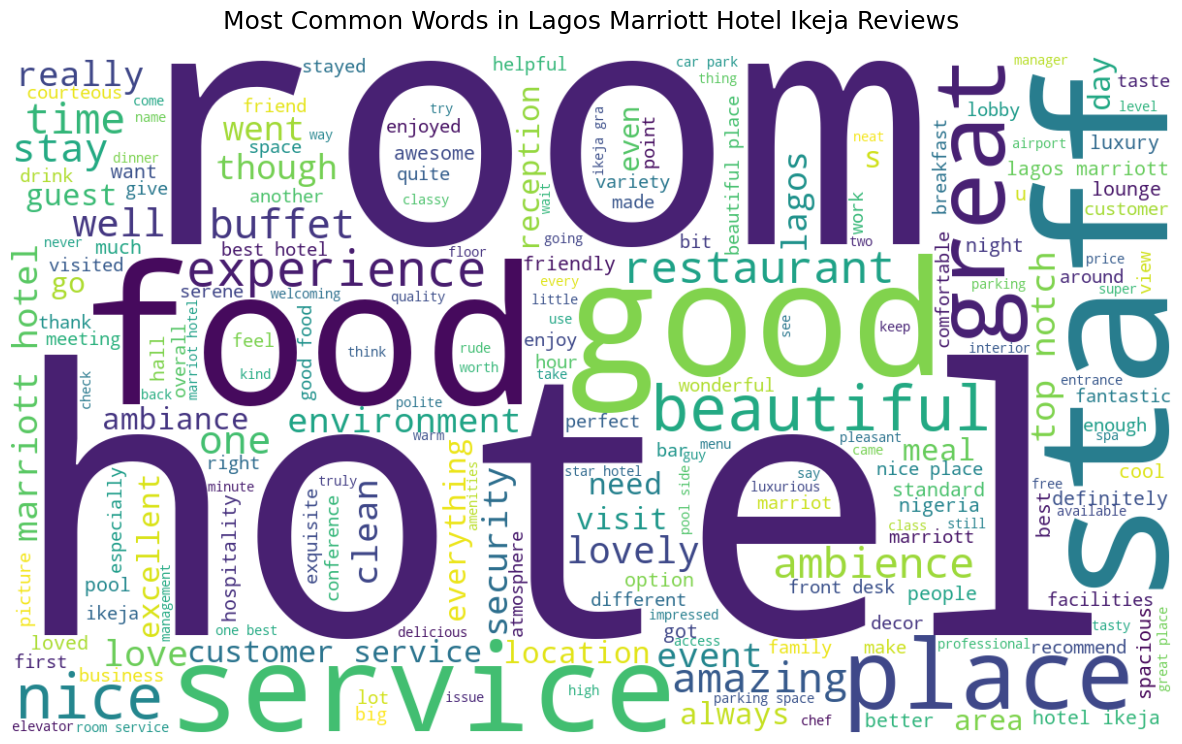

In [72]:
# Generate wordcloud

wordcloud = WordCloud(
    width=1200,
    height=700,
    background_color='white',
    max_words=200,
    colormap='viridis',     
    contour_color='black',
    contour_width=1,
    random_state=42
).generate(filtered_text)


plt.figure(figsize=(15, 9))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Lagos Marriott Hotel Ikeja Reviews', 
          fontsize=18, pad=20)
plt.savefig("marriot_words.png")
plt.show()

## Reports on most common words

**Note: The bigger the word, the more common it is**
 - The most common words tend to be positive
 - It resonates food, stay, experience and positive words

# Sentiment Analyses

In [28]:
sia = SentimentIntensityAnalyzer()
new_df['sentiment'] = new_df['review_text'].apply(lambda x: sia.polarity_scores(x)['compound'])

## Difference in most positive and negative word cloud

In [29]:
# Lets find out common words for negative sentiment

neg_text = " ".join(new_df[new_df["sentiment"] <= 0]["review_text"].astype(str))

stop_words = set(stopwords.words("english"))

# remove stopwords from text
text = " ".join(
    word for word in neg_text.split()
    if word.lower() not in stop_words
)

# Lets find out common words for positive sentiment

pos_text = " ".join(new_df[new_df["sentiment"] > 0]["review_text"].astype(str))

stop_words = set(stopwords.words("english"))

# remove stopwords from text
postext = " ".join(
    word for word in pos_text.split()
    if word.lower() not in stop_words
)

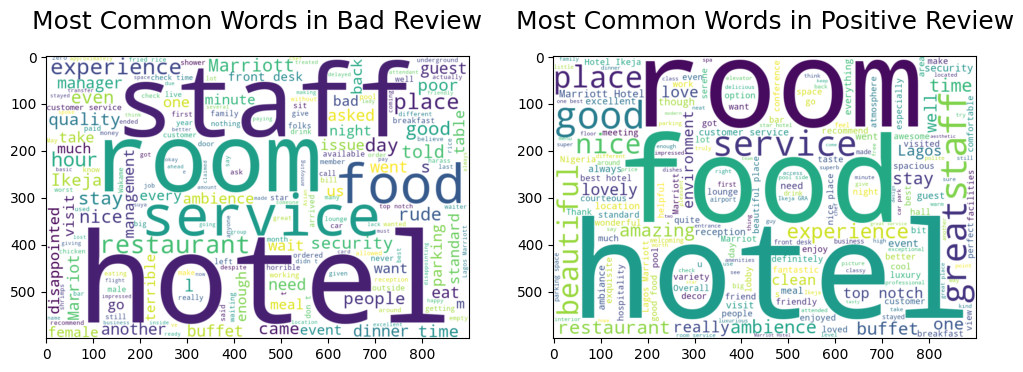

In [73]:
# Most Common words in Negative review

# Negative
wordcloud = WordCloud(
    width=900,
    height=600,
    background_color='white',
    max_words=200,
    colormap='viridis',     
    contour_color='black',
    contour_width=1,
    random_state=42
).generate(text)

# Positive
pos_wordcloud = WordCloud(
    width=900,
    height=600,
    background_color='white',
    max_words=200,
    colormap='viridis',     
    contour_color='black',
    contour_width=1,
    random_state=42
).generate(postext)

fig, axes = plt.subplots(1, 2, figsize=(12, 9))
axes[0].imshow(wordcloud, interpolation='bilinear')
axes[1].imshow(pos_wordcloud, interpolation='bilinear')
axes[0].set_title('Most Common Words in Bad Review', 
          fontsize=18, pad=20)
axes[1].set_title('Most Common Words in Positive Review', 
          fontsize=18, pad=20)
plt.savefig("pos_neg.png")
plt.show()

# Report from word cloud
**Consistent large word appearance in Staff, Room, Service, Hotel and Food in both kind of review reflects what drives customer satisfaction in the hotel**
- Although staffs are mentioned in both review categories. looking at the word sizetaffs tend to appear more in bad reviews
- Also for food, it appears in both kind of reviews. while its visible in bad review, it appears more in positive reviews. In the bad review, words related to food like dinner, buffet, meal, restaurants are also constant
- Complaints of rudeness in the bad reviews raises concerns on staff behaviour
- Praises of aesthetics in the positive review section supported by large word like "beautiful"


**In Summary**
- Major driver of bad reviews are Staffs, Food, Service and Rooms

# Using Zero Shot Classification from HuggingFace

**It takes reviews and classify it to one of the following provided classification**

In [31]:
classifier = pipeline(
    "zero-shot-classification", 
    model="facebook/bart-large-mnli",
)

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

In [32]:
# Pick the most common words in the word cloud as c;ass

labels = ["Food Related", "Staff Related", "Services Related", "Room Related"]

# Function to classify
def classify(text):
    result = classifier(text, labels, multi_label=False)

    return {
        'class': result['labels'][0],
        'confidence': round(result['scores'][0], 4)
    }

In [33]:
results = new_df['review_text'].apply(classify)

In [34]:
new_df["class"] = [r["class"] for r in results]
new_df["confidence"] = [r["confidence"] for r in results]

In [35]:
def sentiment(text):
    if text > 0:
        return "Positive Review"
    else:
        return "Negative Review"

In [36]:
new_df["Sentiment Class"] = new_df["sentiment"].apply(sentiment)

## Checking most common negative and positive review

In [37]:
neg = new_df[new_df["Sentiment Class"] == "Negative Review"]
pos = new_df[new_df["Sentiment Class"] != "Negative Review"]

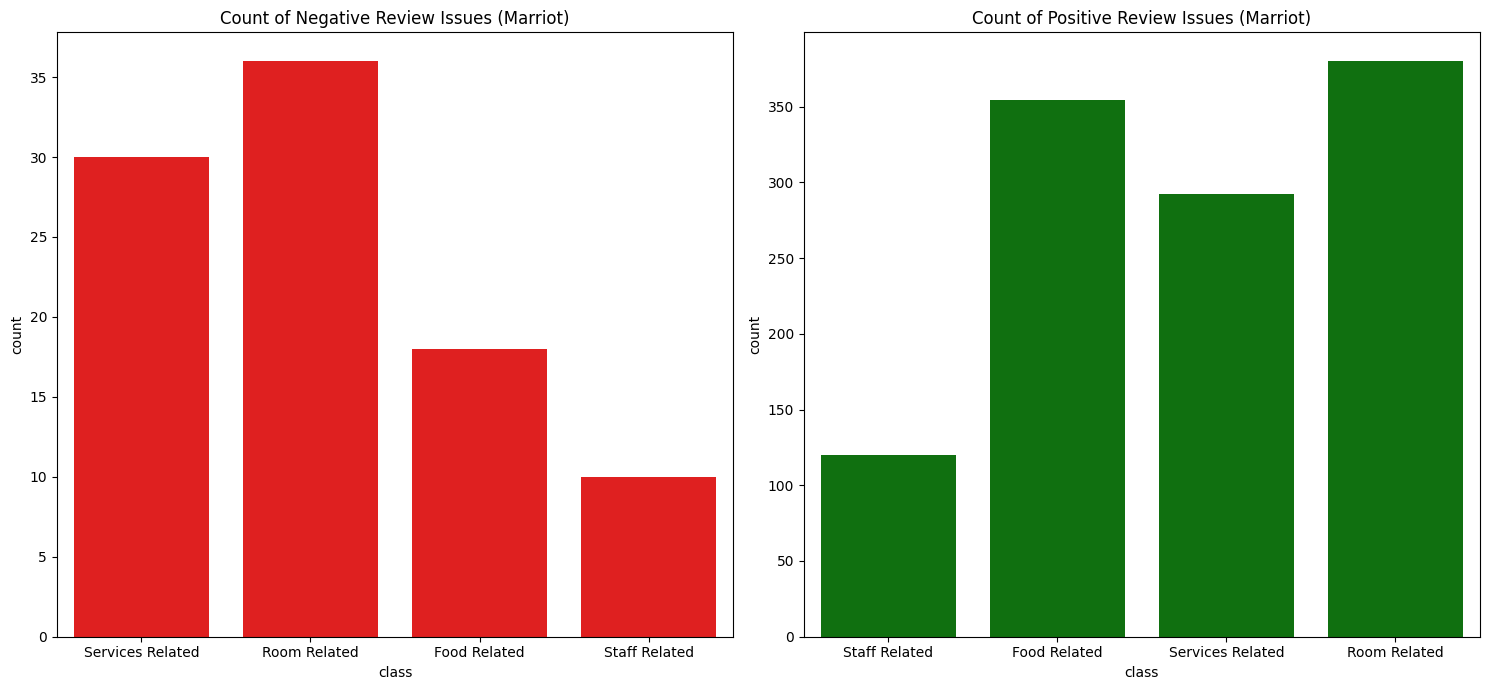

In [80]:
# Countplot
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

sns.countplot(data=neg, x="class", color="red", ax=axes[0])
sns.countplot(data=pos, x="class", color="green", ax=axes[1])
axes[0].set_title("Count of Negative Review Issues (Marriot)")
axes[1].set_title("Count of Positive Review Issues (Marriot)")
plt.tight_layout()
plt.savefig("neg_pos.png")
plt.show()

In [41]:
df.to_csv("Marriot_Public_Reviews.csv", index=False)

In [88]:
# I want to see the negative percentage of each class
## create a loop for each class
for clas in neg["class"].unique():
    nega = neg[neg["class"] == clas]
    posi = pos[pos["class"] == clas]

    percentage = len(nega) / (len(nega) + len(posi))

    print(f"{clas}: {percentage:.2f}")
    print("=" * 50)

Services Related: 0.09
Room Related: 0.09
Food Related: 0.05
Staff Related: 0.08


In [42]:
new_df["Sentiment Class"].value_counts()

Sentiment Class
Positive Review    1146
Negative Review      94
Name: count, dtype: int64

## Lets See The Month Year and day bad reviews were posted the most

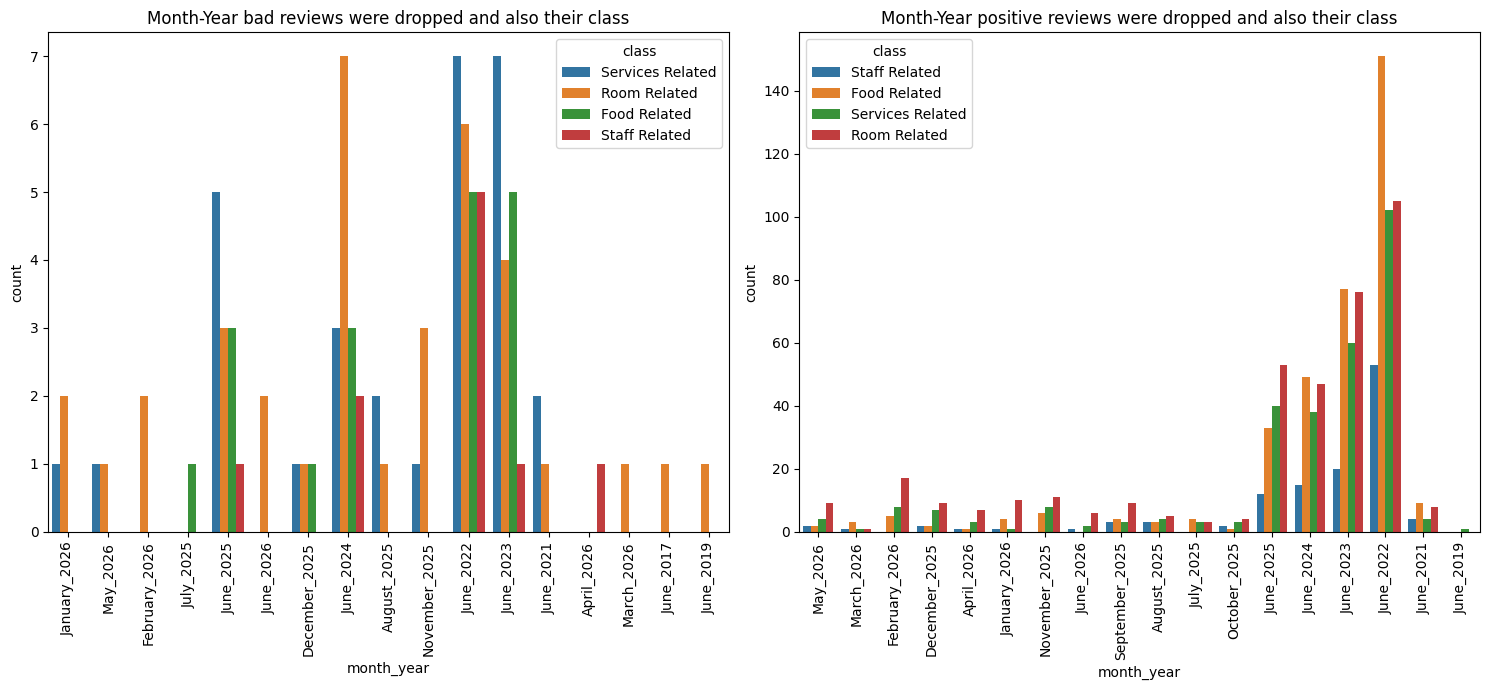

In [82]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

sns.countplot(data=neg, x="month_year", hue="class", ax=axes[0])
sns.countplot(data=pos, x="month_year", hue="class", ax=axes[1])
axes[0].tick_params(axis="x", rotation=90)
axes[1].tick_params(axis="x", rotation=90)
axes[0].set_title("Month-Year bad reviews were dropped and also their class")
axes[1].set_title("Month-Year positive reviews were dropped and also their class")
plt.tight_layout()
plt.savefig("month-year.png")
plt.show()

## Reports on Complaints and the Timing
**Month-Year**
- Most complaints this year are room related which are 8 complaints in total, seconded by service related complaints which are 2 in total and then 1 staff related complaints
- Most complaints came from 2022, 2023, 2024 and 2025 mostly services, room and food related with service and room related complaint at it peak in the previously mentioned year

## Reports on positive reviews and the timing

**Month-Year**
- Reviews were most constant in the year 2022, 2023, 2024 and 2025, with food related reviews peaking at 
- Reviews for 2026 are more of room, service and food related


# Building predictive models to classify reviews into positive and negative

In [45]:
# i need to get it into huggingface dataset
data = new_df[["review_text", "Sentiment Class"]]

In [46]:
data["Sentiment Class"].value_counts()

Sentiment Class
Positive Review    1146
Negative Review      94
Name: count, dtype: int64

In [47]:
# data needs sampling
# First, let me convert labels to nemeric
data["label"] = data["Sentiment Class"].map({"Positive Review": 1, "Negative Review": 0})
# drop the cat col
data.drop("Sentiment Class", axis=1, inplace=True)

# Split data to X and y
X = data["review_text"].values.reshape(-1, 1)
y= data["label"].values.reshape(-1, 1)

#Before sampling, let me split to avoid overfitting include stratify
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# resample
ros = RandomOverSampler(random_state=42)
X_resample, y_resample = ros.fit_resample(X_train, y_train)

C:\Users\USER\AppData\Local\Temp\ipykernel_21600\2376260983.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["label"] = data["Sentiment Class"].map({"Positive Review": 1, "Negative Review": 0})
C:\Users\USER\AppData\Local\Temp\ipykernel_21600\2376260983.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop("Sentiment Class", axis=1, inplace=True)


In [48]:
# Put both in a pandas dataframe so we can pull into huggingface dataset easily

train_data = pd.DataFrame({"Text": X_resample.flatten(), "label": y_resample})
test_data = pd.DataFrame({"Text": X_test.flatten(), "label": y_test.flatten()})

In [49]:
train_dataset = Dataset.from_pandas(train_data)
test_dataset = Dataset.from_pandas(test_data)

In [50]:
# Tokenization: we use opensourced tokenizer
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [51]:
# Define tokenizer function
def tokenize(examples):
    return tokenizer(examples["Text"], padding="max_length", truncation=True, max_length=64)

In [52]:
# Lets tokenize our datasets
tokenized_train = train_dataset.map(tokenize, batched=True)
tokenized_test = test_dataset.map(tokenize, batched=True)

Map:   0%|          | 0/1834 [00:00<?, ? examples/s]

Map:   0%|          | 0/248 [00:00<?, ? examples/s]

In [53]:
# Load Pretrained Model
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [54]:
# Configure Training
accuracy = evaluate.load("accuracy")
f1 = evaluate.load("f1")
precision = evaluate.load("precision")
recall = evaluate.load("recall")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.argmax(torch.tensor(logits), dim=1)
    results = {
        "accuracy": accuracy.compute(predictions=predictions, references=labels)["accuracy"],
        "f1": f1.compute(predictions=predictions, references=labels, average="binary")["f1"],
        "precision": precision.compute(predictions=predictions, references=labels, average="binary")["precision"],
        "precision_neg": precision.compute(predictions=predictions, references=labels, pos_label=0, average="binary")["precision"],
        "recall": recall.compute(predictions=predictions, references=labels, average="binary")["recall"]
    }
    return results

training_args = TrainingArguments(
    output_dir="./marriot_model",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=1,
    load_best_model_at_end=True,
    report_to="none"
)

In [55]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)

trainer.train()

C:\Users\USER\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Precision Neg,Recall
1,0.000819,0.222834,0.959677,0.978070,0.982379,0.714286,0.973799
2,0.000371,0.173097,0.971774,0.984946,0.970339,1.000000,1.000000
3,0.000258,0.198207,0.971774,0.984946,0.970339,1.000000,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

C:\Users\USER\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

C:\Users\USER\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=1377, training_loss=0.0810548926493184, metrics={'train_runtime': 1003.7684, 'train_samples_per_second': 5.481, 'train_steps_per_second': 1.372, 'total_flos': 91104453425664.0, 'train_loss': 0.0810548926493184, 'epoch': 3.0})

In [56]:
# Saving artifacts

output_dir = "./marriot_sentiment"

model.save_pretrained(output_dir)
tokenizer.save_pretrained(output_dir)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./marriot_sentiment\\tokenizer_config.json',
 './marriot_sentiment\\tokenizer.json')

In [57]:
# Load and test model

fine_tuned_model = AutoModelForSequenceClassification.from_pretrained(output_dir)
updated_tokenizer = AutoTokenizer.from_pretrained(output_dir)

test_reviews = [
    "Marriot is much more better than radisson blu, their food is worth the price",
    "I don't like how they treat their staff at marriot, they should take them as priority also",
    "Please radisson blu is than your nonsense food and the rubbish you guys are doing here in marriot"
]

for test in test_reviews:
    inputs = updated_tokenizer(test, return_tensors="pt", padding=True, truncation=True, max_length=64)

    with torch.no_grad():
        outputs = fine_tuned_model(**inputs)

    predicted_id = torch.argmax(outputs.logits, dim=-1).item()
    sentiment = "Positive" if predicted_id == 1 else "Negative"
    confidence = torch.softmax(outputs.logits, dim=-1)[0][predicted_id].item()

    print(test)
    print(sentiment)
    print(confidence)
    print("==" * 50)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Marriot is much more better than radisson blu, their food is worth the price
Positive
0.9997029900550842
I don't like how they treat their staff at marriot, they should take them as priority also
Positive
0.9992152452468872
Please radisson blu is than your nonsense food and the rubbish you guys are doing here in marriot
Positive
0.9920787215232849


In [59]:
import folium
from geopy.distance import geodesic


marriott = [6.5848714, 3.3492881]
radisson = [6.5820000, 3.3586641]

# Create map
m = folium.Map(location=[6.59, 3.347], zoom_start=15, tiles="CartoDB positron")

# Marriott
folium.Marker(
    location=marriott,
    popup="<b>Lagos Marriott Hotel Ikeja</b>",
    icon=folium.Icon(color="blue", icon="star")
).add_to(m)

# Radisson Blu
folium.Marker(
    location=radisson,
    popup="<b>Radisson Blu Ikeja</b>",
    icon=folium.Icon(color="red", icon="star")
).add_to(m)

# Distance line
distance = geodesic(marriott, radisson).meters

folium.PolyLine(
    locations=[marriott, radisson],
    color="purple",
    weight=4,
    opacity=0.85,
    tooltip=f"Distance: {distance:.2f} m"
).add_to(m)

# Title
title_html = f'''
             <h3 align="center" style="font-size:16px"><b>Lagos Marriott Hotel Ikeja vs Radisson Blu Ikeja</b></h3>
             <h4 align="center" style="font-size:14px">Distance: {distance:.2f} m</h4>
             '''
m.get_root().html.add_child(folium.Element(title_html))

m

In [60]:
# Save the map as an HTML file
m.save("lagos_hotels_map.html")

print("✅ Map saved successfully as 'lagos_hotels_map.html'")

✅ Map saved successfully as 'lagos_hotels_map.html'
